In [1]:
import pickle
import numpy as np
import os
import torch

# --- 实验配置 ---
method = 'AdaRHD_S' 
methodopt = '20'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 实验配置清单：学习率 -> 对应的 Epochs
data_configs = {
    "0.05":  3000, 
    "0.1":   3000, 
    "0.125": 1900, 
    "0.5":   700,  
    "1.0":   700   
}

In [2]:
import pickle
import numpy as np
import os
import torch

# --- 实验配置 (针对 lr=1.0) ---
lr = 1.0
max_epochs = 700 
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 拼接路径
file_path = os.path.join(results_dir, f'hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl')

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# Get the loss data (使用 loss_upper 代替示例中的 total_hgradnorm)
all_gradnorms = data['loss_upper']
new_all_gradnorms = []
for i in range(len(all_gradnorms)):
    # 模仿示例：使用 cummin 记录收敛过程中的最小损失/梯度
    # 使用 [0] 获取数值，确保转为 1D
    new_all_gradnorms.append(all_gradnorms[i].reshape(1, -1).cummin(dim=1)[0].reshape(-1))
all_gradnorms = new_all_gradnorms

# Determine how many experiments we have
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data")

# Prepare arrays for storing padded data
train_gradnorms = []

# Process each experiment
for i in range(num_experiments):
    # Extract data and reshape
    train_gradnorm = all_gradnorms[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(train_gradnorm)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # If less than max_epochs, pad with the last value
    if num_epochs < max_epochs:
        # 增加 .cpu().numpy() 确保计算兼容性
        train_gradnorm = np.pad(train_gradnorm.cpu().numpy(), (0, max_epochs - num_epochs), 
                                'constant', constant_values=train_gradnorm[-1].item())
    else:
        # If more than max_epochs, truncate
        train_gradnorm = train_gradnorm[:max_epochs]
        train_gradnorm = train_gradnorm.cpu().numpy()
    
    # Add to our list
    train_gradnorms.append(train_gradnorm)

# Convert lists to numpy arrays for easier manipulation
# 保持序号为 1
train_gradnorms1 = np.array(train_gradnorms)

print(f"lr={lr} 处理完成: train_gradnorms1.shape = {train_gradnorms1.shape}")

Found 5 experiments in the data
Experiment 1 has 700 epochs
Experiment 2 has 700 epochs
Experiment 3 has 700 epochs
Experiment 4 has 700 epochs
Experiment 5 has 700 epochs
lr=1.0 处理完成: train_gradnorms1.shape = (5, 700)


In [3]:
import pickle
import numpy as np
import os
import torch

# --- 实验配置 (针对 lr=0.5) ---
lr = 0.5
max_epochs = 700  # 对应你记录中的 700 次
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 使用你指定的绝对路径拼接方式
file_path = f'C:/Users/24300/Desktop/Ada_S/results/hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl'

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# Get the loss data (使用 loss_upper 代替示例中的 total_hgradnorm)
all_gradnorms = data['loss_upper']
new_all_gradnorms = []
for i in range(len(all_gradnorms)):
    # 保持 cummin 逻辑：记录收敛过程中的历史最小 Loss
    # 使用 reshape(1, -1) 确保符合 cummax/cummin 对维度的要求
    new_all_gradnorms.append(all_gradnorms[i].reshape(1, -1).cummin(dim=1)[0].reshape(-1))
all_gradnorms = new_all_gradnorms

# Determine how many experiments we have
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data for lr={lr}")

# Prepare arrays for storing padded data
train_gradnorms = []

# Process each experiment
for i in range(num_experiments):
    # Extract data and reshape
    train_gradnorm = all_gradnorms[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(train_gradnorm)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # 填充或截断至 700 (max_epochs)
    if num_epochs < max_epochs:
        # 增加 .cpu().numpy() 并使用 .item() 获取填充值
        train_gradnorm_np = np.pad(train_gradnorm.cpu().numpy(), (0, max_epochs - num_epochs), 
                                  'constant', constant_values=train_gradnorm[-1].item())
    else:
        # 如果超出则截断
        train_gradnorm_np = train_gradnorm[:max_epochs].cpu().numpy()
    
    # Add to our list
    train_gradnorms.append(train_gradnorm_np)

# Convert lists to numpy arrays for easier manipulation
# 变量名序号改为 2
train_gradnorms2 = np.array(train_gradnorms)

print(f"lr={lr} 处理完成，变量 train_gradnorms2 已生成，矩阵形状: {train_gradnorms2.shape}")

Found 5 experiments in the data for lr=0.5
Experiment 1 has 700 epochs
Experiment 2 has 700 epochs
Experiment 3 has 700 epochs
Experiment 4 has 700 epochs
Experiment 5 has 700 epochs
lr=0.5 处理完成，变量 train_gradnorms2 已生成，矩阵形状: (5, 700)


In [4]:
import pickle
import numpy as np
import os
import torch

# --- 实验配置 (针对 lr=0.125) ---
lr = 0.125
max_epochs = 1900  # 对应你记录中的 1900 次
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 使用你指定的绝对路径逻辑
file_path = f'C:/Users/24300/Desktop/Ada_S/results/hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl'

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# Get the loss data (使用 loss_upper 键以匹配你的 stats 字典存储逻辑)
all_gradnorms = data['loss_upper']
new_all_gradnorms = []
for i in range(len(all_gradnorms)):
    # 保持 cummin 逻辑：记录收敛过程中的历史最小 Loss
    # 确保维度处理符合 cummin 要求
    new_all_gradnorms.append(all_gradnorms[i].reshape(1, -1).cummin(dim=1)[0].reshape(-1))
all_gradnorms = new_all_gradnorms

# Determine how many experiments we have
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data for lr={lr}")

# Prepare arrays for storing padded data
train_gradnorms = []

# Process each experiment
for i in range(num_experiments):
    # Extract data and reshape
    train_gradnorm = all_gradnorms[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(train_gradnorm)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # 填充或截断至 1900 (max_epochs)
    if num_epochs < max_epochs:
        # 使用 .cpu().numpy() 确保兼容性，并用最后一个值填充
        train_gradnorm_np = np.pad(train_gradnorm.cpu().numpy(), (0, max_epochs - num_epochs), 
                                  'constant', constant_values=train_gradnorm[-1].item())
    else:
        # 超过则截断
        train_gradnorm_np = train_gradnorm[:max_epochs].cpu().numpy()
    
    # Add to our list
    train_gradnorms.append(train_gradnorm_np)

# Convert lists to numpy arrays for easier manipulation
# 变量名序号改为 3
train_gradnorms3 = np.array(train_gradnorms)

print(f"lr={lr} 处理完成，变量 train_gradnorms3 形状为: {train_gradnorms3.shape}")

Found 5 experiments in the data for lr=0.125
Experiment 1 has 1900 epochs
Experiment 2 has 1900 epochs
Experiment 3 has 1900 epochs
Experiment 4 has 1900 epochs
Experiment 5 has 1900 epochs
lr=0.125 处理完成，变量 train_gradnorms3 形状为: (5, 1900)


In [5]:
import pickle
import numpy as np
import os
import torch

# --- 实验配置 (针对 lr=0.1) ---
lr = 0.1
max_epochs = 3000  # 对应你记录中的 3000 次
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 路径使用你指定的绝对路径逻辑
file_path = f'C:/Users/24300/Desktop/Ada_S/results/hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl'

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# Get the loss data (使用 loss_upper 代替示例中的字段)
all_gradnorms = data['loss_upper']
new_all_gradnorms = []
for i in range(len(all_gradnorms)):
    # 保持使用 cummin 逻辑，记录收敛下降过程
    # 使用 reshape 处理确保 cummin 维度正确
    new_all_gradnorms.append(all_gradnorms[i].reshape(1, -1).cummin(dim=1)[0].reshape(-1))
all_gradnorms = new_all_gradnorms

# Determine how many experiments we have
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data for lr={lr}")

# Prepare arrays for storing padded data
train_gradnorms = []

# Process each experiment
for i in range(num_experiments):
    # Extract data and reshape
    train_gradnorm = all_gradnorms[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(train_gradnorm)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # 填充或截断至 3000 (max_epochs)
    if num_epochs < max_epochs:
        # 确保转为 cpu numpy，并使用最后一个值填充
        train_gradnorm_np = np.pad(train_gradnorm.cpu().numpy(), (0, max_epochs - num_epochs), 
                                  'constant', constant_values=train_gradnorm[-1].item())
    else:
        # 截断处理
        train_gradnorm_np = train_gradnorm[:max_epochs].cpu().numpy()
    
    # Add to our list
    train_gradnorms.append(train_gradnorm_np)

# Convert lists to numpy arrays for easier manipulation
# 变量名序号改为 4
train_gradnorms4 = np.array(train_gradnorms)

print(f"lr={lr} 处理完成，变量 train_gradnorms4 形状为: {train_gradnorms4.shape}")

Found 5 experiments in the data for lr=0.1
Experiment 1 has 3000 epochs
Experiment 2 has 3000 epochs
Experiment 3 has 3000 epochs
Experiment 4 has 3000 epochs
Experiment 5 has 3000 epochs
lr=0.1 处理完成，变量 train_gradnorms4 形状为: (5, 3000)


In [6]:
import pickle
import numpy as np
import os
import torch

# --- 1. 实验配置 (针对 lr=0.05) ---
lr = 0.05
max_epochs = 3000  # 对应你记录中的 3000 次
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 使用你指定的绝对路径拼接方式
file_path = f'C:/Users/24300/Desktop/Ada_S/results/hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl'

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# --- 2. 提取并处理 Loss 数据 (使用 loss_upper) ---
all_gradnorms = data['loss_upper']
new_all_gradnorms = []
for i in range(len(all_gradnorms)):
    # 保持使用 cummin 逻辑，记录收敛下降过程中的历史最小值
    # reshape(1, -1) 确保符合 PyTorch cummin 函数的维度要求
    new_all_gradnorms.append(all_gradnorms[i].reshape(1, -1).cummin(dim=1)[0].reshape(-1))
all_gradnorms = new_all_gradnorms

# Determine how many experiments we have
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data for lr={lr}")

# Prepare arrays for storing padded data
train_gradnorms_list = []

# --- 3. Padding (填充) 或 Truncate (截断) 循环 ---
for i in range(num_experiments):
    # 提取数据并转为 1D
    train_gradnorm = all_gradnorms[i].reshape(-1)
    num_now = len(train_gradnorm)
    print(f"Experiment {i+1} has {num_now} epochs")
    
    # 填充或截断至 3000 (max_epochs)
    if num_now < max_epochs:
        # 确保转为 cpu numpy，并使用最后一个值填充以保持收敛末端平齐
        train_gradnorm_np = np.pad(train_gradnorm.cpu().numpy(), (0, max_epochs - num_now), 
                                  'constant', constant_values=train_gradnorm[-1].item())
    else:
        # 超过 3000 则截断
        train_gradnorm_np = train_gradnorm[:max_epochs].cpu().numpy()
    
    train_gradnorms_list.append(train_gradnorm_np)

# --- 4. 转换为最终变量 (后缀为 5) ---
train_gradnorms5 = np.array(train_gradnorms_list)

print(f"lr={lr} 处理完成，变量 train_gradnorms5 形状为: {train_gradnorms5.shape}")

Found 5 experiments in the data for lr=0.05
Experiment 1 has 3000 epochs
Experiment 2 has 3000 epochs
Experiment 3 has 3000 epochs
Experiment 4 has 3000 epochs
Experiment 5 has 3000 epochs
lr=0.05 处理完成，变量 train_gradnorms5 形状为: (5, 3000)


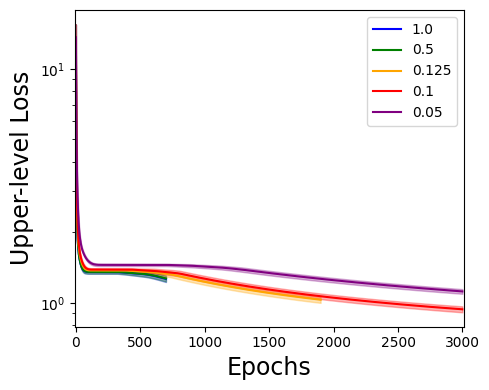

图像已成功保存至: ../fig/robust_dataratio0.05_deep_hyrep_spd_gradnorm_AdaRHD_S_20_bestiter.pdf


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. 计算均值和标准差 (计算 5 组处理好的数据) ---
mean_train_gradnorm1, std_train_gradnorm1 = np.mean(train_gradnorms1, axis=0), np.std(train_gradnorms1, axis=0)
mean_train_gradnorm2, std_train_gradnorm2 = np.mean(train_gradnorms2, axis=0), np.std(train_gradnorms2, axis=0)
mean_train_gradnorm3, std_train_gradnorm3 = np.mean(train_gradnorms3, axis=0), np.std(train_gradnorms3, axis=0)
mean_train_gradnorm4, std_train_gradnorm4 = np.mean(train_gradnorms4, axis=0), np.std(train_gradnorms4, axis=0)
mean_train_gradnorm5, std_train_gradnorm5 = np.mean(train_gradnorms5, axis=0), np.std(train_gradnorms5, axis=0)

# --- 2. 创建画布 (严格遵循优秀示例的 5x4 尺寸) ---
plt.figure(figsize=(5, 4))

# --- 3. 绘制各学习率下的收敛曲线 (使用 semilogy) ---

# lr=1.0 (Suffix 1)
epochs1 = range(len(mean_train_gradnorm1))
plt.semilogy(epochs1, mean_train_gradnorm1, color='blue', label='1.0')
plt.fill_between(epochs1, mean_train_gradnorm1 - 0.5*std_train_gradnorm1, 
                 mean_train_gradnorm1 + 0.5*std_train_gradnorm1, color='blue', alpha=0.3)

# lr=0.5 (Suffix 2)
epochs2 = range(len(mean_train_gradnorm2))
plt.semilogy(epochs2, mean_train_gradnorm2, color='green', label='0.5')
plt.fill_between(epochs2, mean_train_gradnorm2 - 0.5*std_train_gradnorm2, 
                 mean_train_gradnorm2 + 0.5*std_train_gradnorm2, color='green', alpha=0.3)

# lr=0.125 (Suffix 3)
epochs3 = range(len(mean_train_gradnorm3))
plt.semilogy(epochs3, mean_train_gradnorm3, color='orange', label='0.125')
plt.fill_between(epochs3, mean_train_gradnorm3 - 0.5*std_train_gradnorm3, 
                 mean_train_gradnorm3 + 0.5*std_train_gradnorm3, color='orange', alpha=0.3)

# lr=0.1 (Suffix 4)
epochs4 = range(len(mean_train_gradnorm4))
plt.semilogy(epochs4, mean_train_gradnorm4, color='red', label='0.1')
plt.fill_between(epochs4, mean_train_gradnorm4 - 0.5*std_train_gradnorm4, 
                 mean_train_gradnorm4 + 0.5*std_train_gradnorm4, color='red', alpha=0.3)

# lr=0.05 (Suffix 5)
epochs5 = range(len(mean_train_gradnorm5))
plt.semilogy(epochs5, mean_train_gradnorm5, color='purple', label='0.05')
plt.fill_between(epochs5, mean_train_gradnorm5 - 0.5*std_train_gradnorm5, 
                 mean_train_gradnorm5 + 0.5*std_train_gradnorm5, color='purple', alpha=0.3)

# --- 4. 图表细节修饰 ---
plt.xlabel('Epochs', fontsize=17)
plt.ylabel('Upper-level Loss', fontsize=17) 

# 设定 X 轴范围 (根据最大 3000 轮对齐)
plt.xlim([-10, 3010])

plt.legend()
plt.tight_layout()

# --- 5. 保存图表 ---
os.makedirs('../fig/', exist_ok=True)
save_path = f'../fig/robust_dataratio{ratio}_deep_hyrep_spd_gradnorm_{method}_{methodopt}_bestiter.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')

plt.show()
print(f"图像已成功保存至: {save_path}")